In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import joblib
%matplotlib inline

In [2]:
df = pd.read_csv("data/student-lifestyle-and-stress-dataset.csv")
df

,Student_Type,Sleep_Hours,Study_Hours,Social_Media_Hours,Attendance,Exam_Pressure,Family_Support,Month,Stress_Level
0,school,6.868702,1.711722,3.176942,NaN,8.0,7.0,2.0,1
1,school,8.519088,3.251084,3.880787,93.978465,6.0,4.0,3.0,1
2,college,4.498770,6.306885,2.936172,64.421253,7.0,1.0,12.0,1
3,school,8.591223,2.384922,5.222832,81.868960,2.0,7.0,7.0,0
4,college,5.329293,9.345179,7.815869,85.847982,5.0,6.0,10.0,1
...,...,...,...,...,...,...,...,...,...
25495,college,7.803069,7.328193,2.018277,75.435607,5.0,1.0,12.0,0
25496,school,6.734607,2.680109,3.355559,63.387386,8.0,9.0,2.0,1
25497,college,7.701671,2.631250,2.948252,79.818930,4.0,3.0,4.0,1
25498,school,5.903426,3.450424,6.823894,96.680773,2.0,6.0,6.0,0


<h1>EDA</h1>

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25500 entries, 0 to 25499
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Student_Type        24248 non-null  object 
 1   Sleep_Hours         24167 non-null  float64
 2   Study_Hours         24223 non-null  float64
 3   Social_Media_Hours  24188 non-null  float64
 4   Attendance          24195 non-null  float64
 5   Exam_Pressure       24230 non-null  float64
 6   Family_Support      24209 non-null  float64
 7   Month               24186 non-null  float64
 8   Stress_Level        25500 non-null  int64  
dtypes: float64(7), int64(1), object(1)
memory usage: 1.8+ MB


In [4]:
df.describe()

,Sleep_Hours,Study_Hours,Social_Media_Hours,Attendance,Exam_Pressure,Family_Support,Month,Stress_Level
count,24167.000000,24223.000000,24188.000000,24195.000000,24230.000000,24209.000000,24186.000000,25500.000000
mean,6.458948,4.696477,3.555614,81.270961,5.369748,5.798298,6.500992,0.299882
std,1.504228,2.240148,1.901528,12.052045,2.394003,2.232371,3.455308,0.458215
min,2.008586,-1.433434,0.000040,-5.000000,1.000000,1.000000,1.000000,0.000000
25%,5.438360,3.078230,2.152249,73.738894,4.000000,4.000000,3.000000,0.000000
50%,6.542566,4.538138,3.500709,81.942959,5.000000,6.000000,6.000000,0.000000
75%,7.531571,6.135670,4.864312,90.106859,7.000000,7.000000,10.000000,1.000000
max,9.997527,22.444460,9.962134,120.000000,10.000000,10.000000,12.000000,1.000000


In [5]:
target = "Stress_Level"

In [6]:
df[target].nunique()

2

In [7]:
df[target].value_counts()

Stress_Level
0    17853
1     7647
Name: count, dtype: int64

In [8]:
summary = pd.DataFrame({
    "Count": [
        df.isna().sum().sum(),
        df.duplicated().sum(), 
        df.select_dtypes(include=['object', 'category']).shape[1], 
        df.select_dtypes(include=np.number).shape[1],
    ],
    "Percent": [
        df.isna().sum().sum() / df.size * 100,
        df.duplicated().sum() / len(df) * 100, 
        df.select_dtypes(include=['object', 'category']).shape[1] / len(df.columns) * 100,
        df.select_dtypes(include=np.number).shape[1] / len(df.columns) * 100,
    ]
},
index=["Missing Values", "Duplicated Data", "Text Columns", "Numeric Columns"])

In [9]:
summary

,Count,Percent
Missing Values,10354,4.511547
Duplicated Data,24,0.094118
Text Columns,1,11.111111
Numeric Columns,8,88.888889


In [10]:
df_percent = df[target].value_counts(normalize=True) * 100
df_percent

Stress_Level
0    70.011765
1    29.988235
Name: proportion, dtype: float64

<h1>visualization</h1>

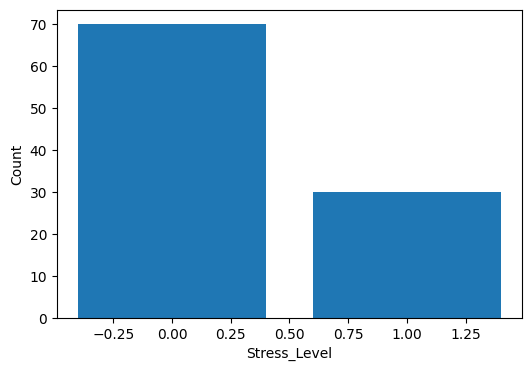

In [11]:
plt.figure(figsize=(6, 4))

plt.bar(df_percent.index, df_percent.values)
plt.xlabel(target)
plt.ylabel("Count")

plt.show()

In [12]:
missing = df.isna().mean().mul(100).sort_values(ascending=False)
missing = missing[missing>0] 
missing

Sleep_Hours           5.227451
Month                 5.152941
Social_Media_Hours    5.145098
Attendance            5.117647
Family_Support        5.062745
Study_Hours           5.007843
Exam_Pressure         4.980392
Student_Type          4.909804
dtype: float64

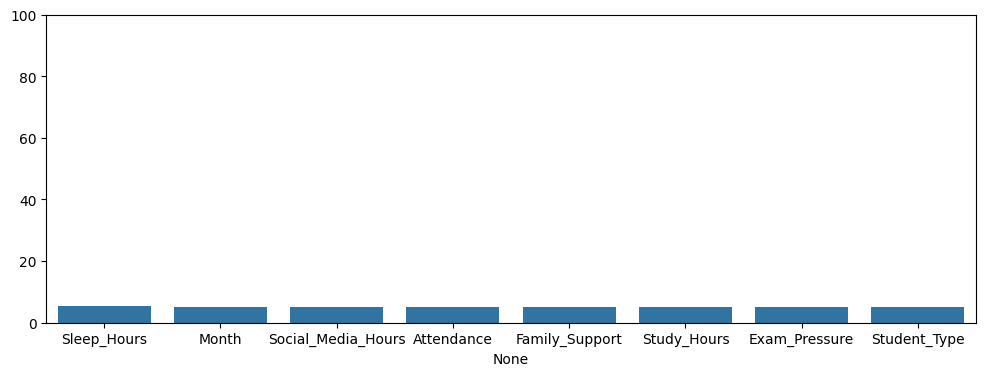

In [13]:
plt.figure(figsize=(12, 4))
sns.barplot(
    x=missing.index, 
    y=missing.values,
)
plt.ylim(0, 100)
plt.show()

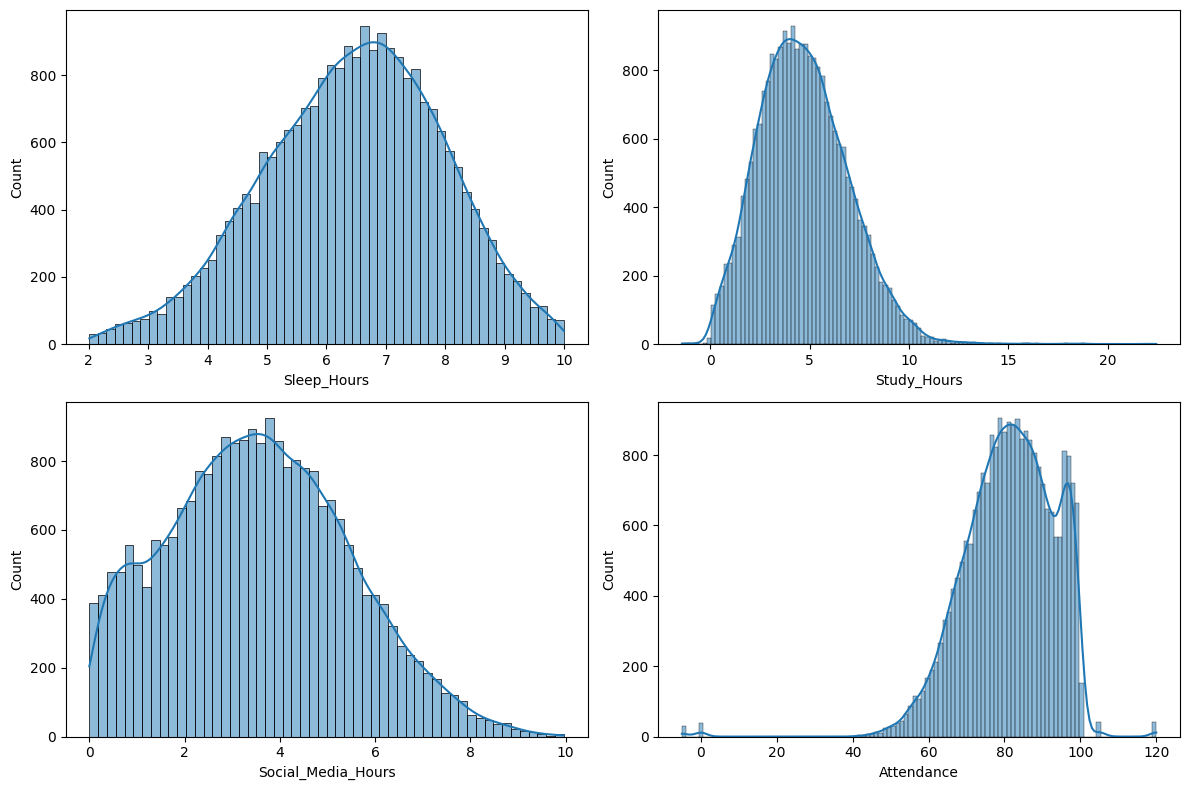

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i , feature in enumerate(df.columns[1:5]):
    sns.histplot(
        data=df,
        x=feature, 
        kde=True, 
        ax=axes[i]
    )

plt.tight_layout()
plt.show()

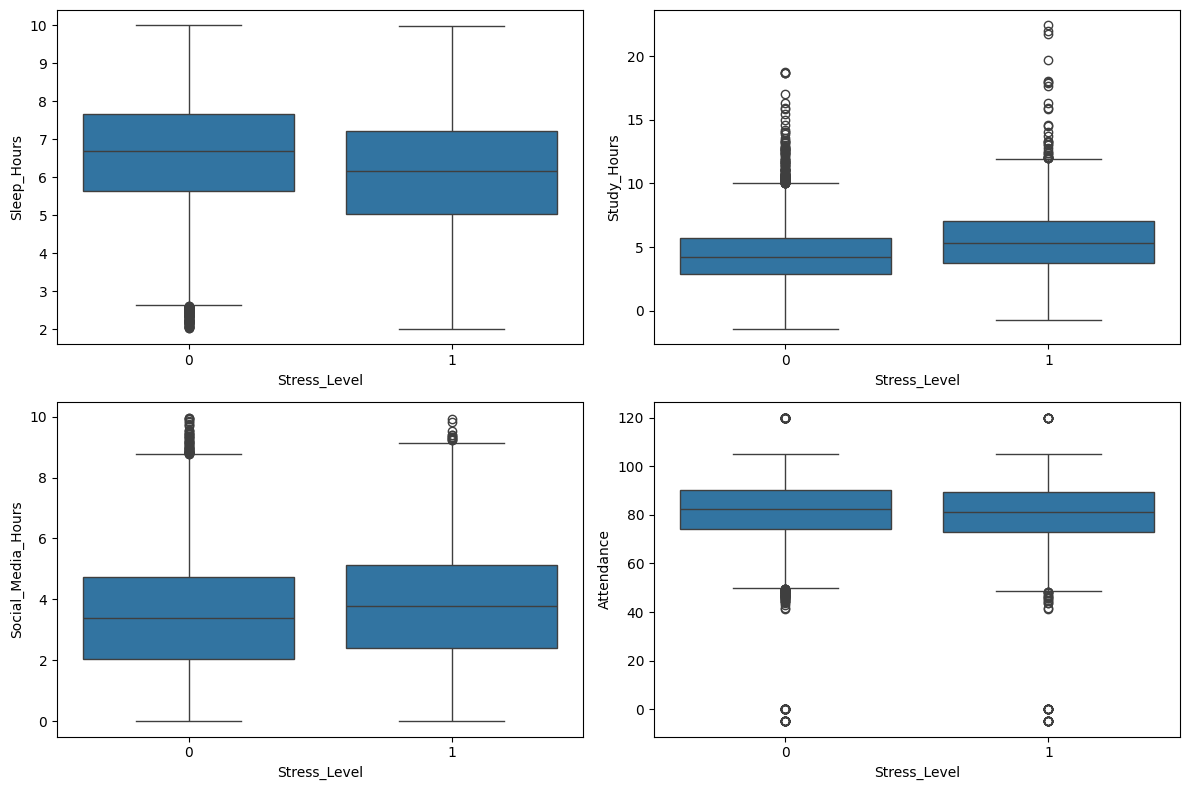

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
for i, feature in enumerate(df.columns[1:5]):
    sns.boxplot(
        data=df,
        x=target,
        y=feature, 
        ax=axes[i]
    )

plt.tight_layout(), 
plt.show()

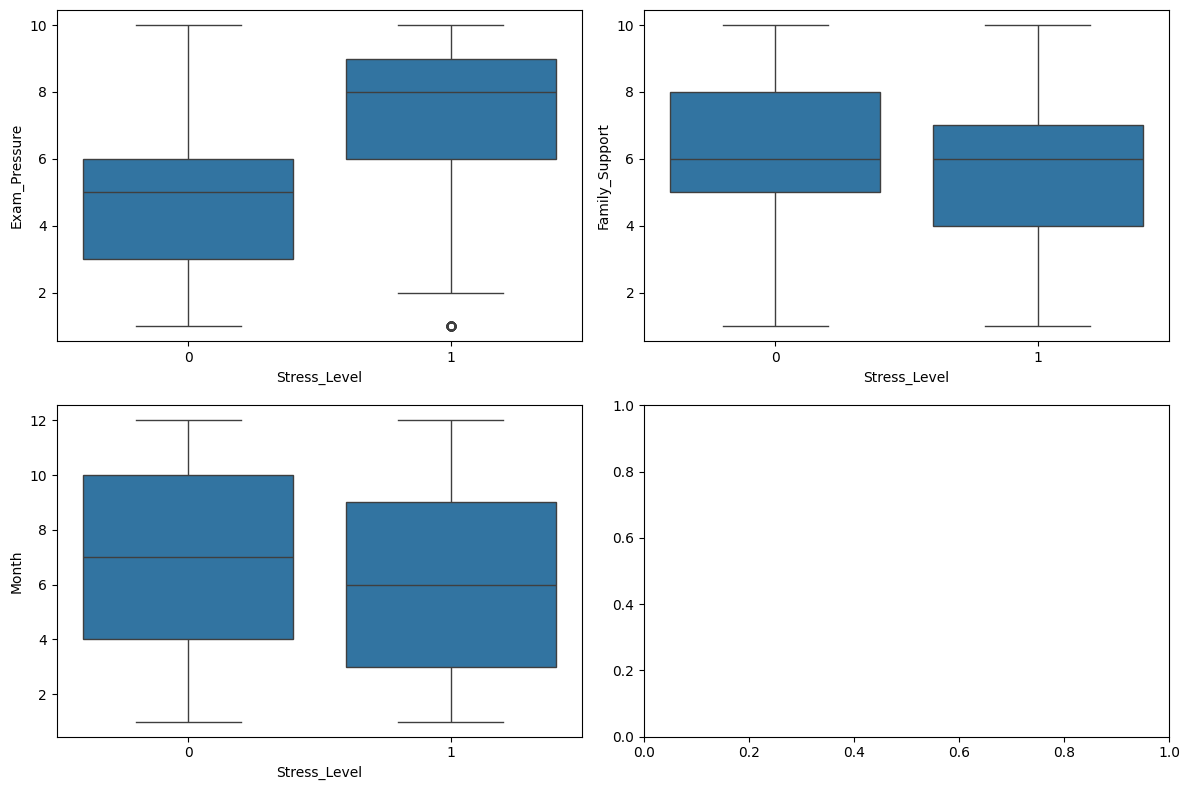

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
for i, feature in enumerate(df.columns[5:-1]):
    sns.boxplot(
        data=df,
        x=target,
        y=feature, 
        ax=axes[i]
    )

plt.tight_layout(), 
plt.show()

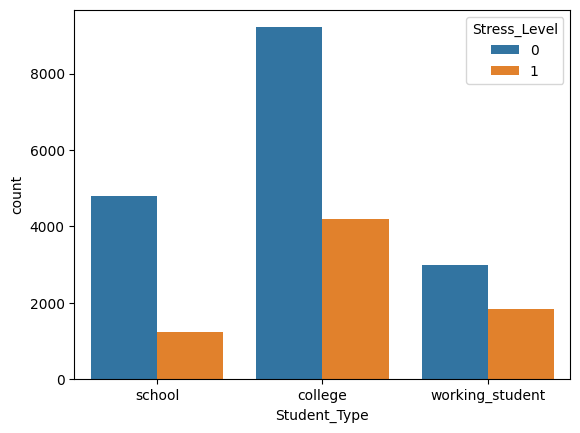

In [17]:
sns.countplot(
    data=df, 
    x="Student_Type", 
    hue=target
)
plt.show()

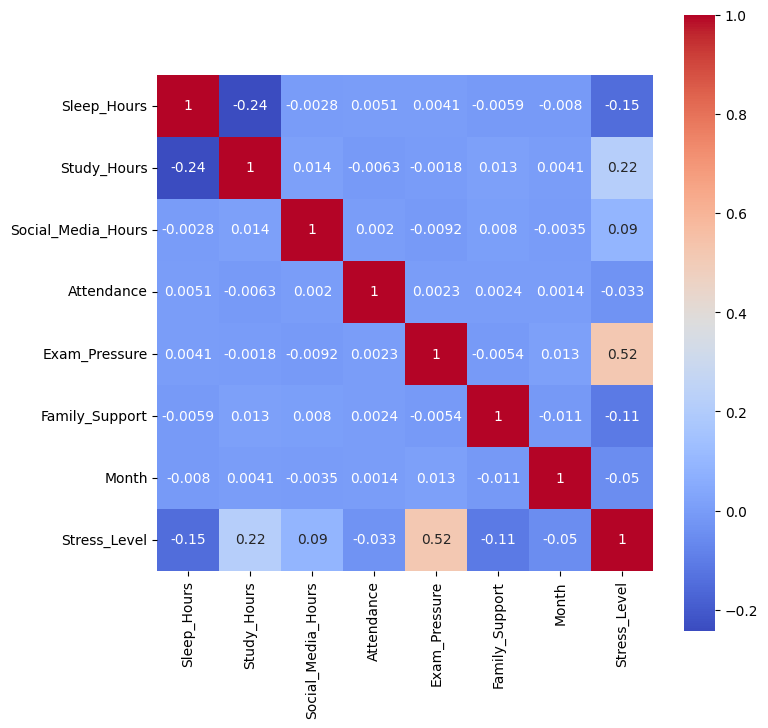

In [18]:
plt.figure(figsize=(8, 8))
corr = df.corr(numeric_only=True) 
sns.heatmap(
    corr, 
    annot=True, 
    cmap="coolwarm", 
    square=True
)
plt.show()

<h1>About Data</h1>

<h4>Approximately 30 percent of students had stress level "1"</h4>
<h4>Most students sleep between 6 and 7 hours a day.</h4>
<h4>Most students study for around five hours a day.</h4>
<h4>Most students use social media for four hours a day. </h4>
<h4>there are approximately 400 students who do not use social media during the day.</h4>
<h4>On average, students are absent 20 percent of the time.</h4>
<h4>At working-student, the ratio of stressed students to non-stressed students is relatively high.</h4>

<h1>Data Preprocessing</h1>

In [19]:
df

,Student_Type,Sleep_Hours,Study_Hours,Social_Media_Hours,Attendance,Exam_Pressure,Family_Support,Month,Stress_Level
0,school,6.868702,1.711722,3.176942,NaN,8.0,7.0,2.0,1
1,school,8.519088,3.251084,3.880787,93.978465,6.0,4.0,3.0,1
2,college,4.498770,6.306885,2.936172,64.421253,7.0,1.0,12.0,1
3,school,8.591223,2.384922,5.222832,81.868960,2.0,7.0,7.0,0
4,college,5.329293,9.345179,7.815869,85.847982,5.0,6.0,10.0,1
...,...,...,...,...,...,...,...,...,...
25495,college,7.803069,7.328193,2.018277,75.435607,5.0,1.0,12.0,0
25496,school,6.734607,2.680109,3.355559,63.387386,8.0,9.0,2.0,1
25497,college,7.701671,2.631250,2.948252,79.818930,4.0,3.0,4.0,1
25498,school,5.903426,3.450424,6.823894,96.680773,2.0,6.0,6.0,0


<h3>Remove Duplicates</h3>

In [20]:
df.duplicated().sum()

np.int64(24)

In [21]:
df.drop_duplicates(inplace=True)

<h3>Missing Value</h3>

In [23]:
def routliers(cols):
    df_clean = df.copy()

    for c in cols:
        q1 = df_clean[c].quantile(0.25)
        q3 = df_clean[c].quantile(0.75)
        iqr = q3 - q1 
        lower = q1 - 1.5 * iqr 
        upper = q3 +1.5 * iqr 

        df_clean = df_clean[
            (df_clean[c]>=lower)&
            (df_clean[c]<=upper)
        ]

    return df_clean 

In [24]:
df.columns.tolist()

['Student_Type',
 'Sleep_Hours',
 'Study_Hours',
 'Social_Media_Hours',
 'Attendance',
 'Exam_Pressure',
 'Family_Support',
 'Month',
 'Stress_Level']

In [25]:
outlier_cols_list = ["Sleep_Hours","Study_Hours", "Social_Media_Hours","Attendance"]
df = routliers(df[outlier_cols_list].columns)

In [26]:
df

,Student_Type,Sleep_Hours,Study_Hours,Social_Media_Hours,Attendance,Exam_Pressure,Family_Support,Month,Stress_Level
1,school,8.519088,3.251084,3.880787,93.978465,6.0,4.0,3.0,1
2,college,4.498770,6.306885,2.936172,64.421253,7.0,1.0,12.0,1
3,school,8.591223,2.384922,5.222832,81.868960,2.0,7.0,7.0,0
4,college,5.329293,9.345179,7.815869,85.847982,5.0,6.0,10.0,1
7,college,6.357065,2.827955,6.198479,74.180341,7.0,8.0,6.0,0
...,...,...,...,...,...,...,...,...,...
25495,college,7.803069,7.328193,2.018277,75.435607,5.0,1.0,12.0,0
25496,school,6.734607,2.680109,3.355559,63.387386,8.0,9.0,2.0,1
25497,college,7.701671,2.631250,2.948252,79.818930,4.0,3.0,4.0,1
25498,school,5.903426,3.450424,6.823894,96.680773,2.0,6.0,6.0,0


<h3>Train Test Split</h3>

In [27]:
df = df.dropna(subset=["Student_Type"]).copy()

X = df.iloc[:, :-1]
y = df.iloc[:, -1]

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=10)

<h3>SimpleImputer</h3>

In [29]:
from sklearn.impute import SimpleImputer

numeric_cols = X_train.select_dtypes(include="number").columns

# why not KNNImputer ? Since there are over 25,000 data points—with approximately 5%(per column) containing missing values—that approach was not optimal and resulted in excessively long program execution times.
simple_imputer = SimpleImputer(missing_values=np.nan,strategy="mean")
X_train[numeric_cols] = simple_imputer.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = simple_imputer.transform(X_test[numeric_cols])
joblib.dump(simple_imputer,"pickle_files/simple_imputer.pkl")

['pickle_files/simple_imputer.pkl']

<h3>Encoding & Scaling</h3>

In [30]:
from sklearn.compose import ColumnTransformer 
from sklearn.preprocessing import OneHotEncoder 
from sklearn.preprocessing import StandardScaler 


ct = ColumnTransformer(
    transformers=[
        (
            "encoder",
            OneHotEncoder(),
            [0]
        ), 
        (
            "scaler", 
            StandardScaler(), 
            numeric_cols
        )
    ],
    remainder="passthrough"
)
X_train = ct.fit_transform(X_train)
X_test = ct.transform(X_test)
joblib.dump(ct, "pickle_files/column_transformer.pkl")

['pickle_files/column_transformer.pkl']

<h3>Mutual Info Classif</h3>

In [31]:
from sklearn.feature_selection import mutual_info_classif
mia = mutual_info_classif(X_train, y_train)
mia = pd.Series(mia)
mia

0    0.009573
1    0.009257
2    0.000000
3    0.009327
4    0.025520
5    0.005707
6    0.001577
7    0.145454
8    0.006481
9    0.003465
dtype: float64

<h4>So exam pressure have the most connection to stress and next Study hour</h4>

<h3>Smote</h3>

In [32]:
y_train.value_counts()

Stress_Level
0    11583
1     4828
Name: count, dtype: int64

In [36]:
# from imblearn.over_sampling import SMOTE

# smote = SMOTE(random_state=10)
# X_train, y_train = smote.fit_resample(X_train, y_train)

<h2>Preprocessing Finished</h2>

<h1>Model</h1>

<h3 style="color:blue;">"gridSearch" is also used in the next cell.</h3>

In [33]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    hidden_layer_sizes=(16), 
    activation="relu", 
    solver="adam", 
    batch_size=32,
    max_iter=500, 
    random_state=42
)

In [34]:
mlp.fit(X_train, y_train)
joblib.dump(mlp, "pickle_files/mlp.pkl")

['pickle_files/mlp.pkl']

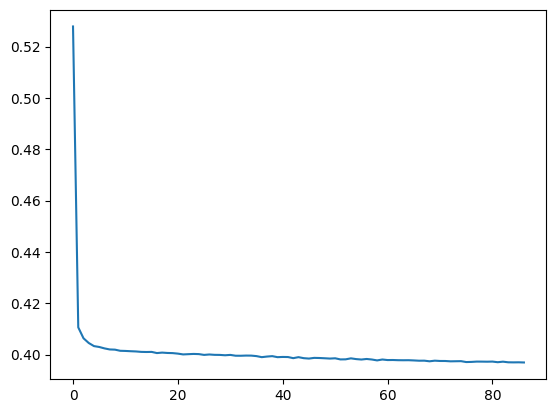

In [35]:
plt.plot(mlp.loss_curve_)

<h1>Grid Search</h1>

<h3><span style="color:red;">important: </span>Since using grid search made the code execution time excessively long, I am proceeding with the initial model.</h3>

In [ ]:
# from sklearn.model_selection import GridSearchCV 

# mlp = MLPClassifier(
#     solver="adam", 
#     max_iter=500, 
#     random_state=10
# )

# params = {
#     "hidden_layer_sizes":[
#         (64,), 
#         (128,),
#         (64, 32), 
#         (128, 64), 
#     ], 
#     "activation":[
#         "relu", 
#         "tanh"
#     ], 
#     "batch_size":[
#         32, 
#         64, 
#         128
#     ], 
#     "alpha": [
#         0.0001,
#         0.001,
#         0.01
#     ],
#     "learning_rate_init": [
#         0.001,
#         0.01
#     ]
# }
# model = GridSearchCV(
#     mlp, 
#     params, 
#     cv=5, 
#     scoring="f1"
# )
# model.fit(X_train, y_train)

<h1>Evaluation</h1>

In [36]:
test_pre = mlp.predict(X_test)

[[1798  178]
 [ 353  568]]


<Axes: >

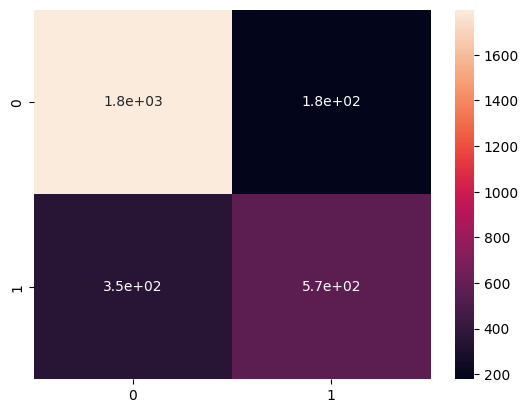

In [37]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score

cm = confusion_matrix(y_test, test_pre)
print(cm)
sns.heatmap(cm, annot=True)

In [38]:
cr = classification_report(y_test, test_pre)
print(cr)

              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1976
           1       0.76      0.62      0.68       921

    accuracy                           0.82      2897
   macro avg       0.80      0.76      0.78      2897
weighted avg       0.81      0.82      0.81      2897



In [39]:
accuracy_score(y_test, test_pre)

0.8167069382119434

<h3>Permutation Importance</h3>

In [40]:
from sklearn.inspection import permutation_importance 

pi = permutation_importance(
    mlp, 
    X_test, 
    y_test, 
    n_repeats=10, 
    random_state=42
)
pi.importances_mean

array([0.01829479, 0.00576458, 0.01194339, 0.01094235, 0.03348291,
       0.00838799, 0.00217466, 0.18584743, 0.01128754, 0.00372799])

<h3>SHAP</h3>

In [41]:
feature_names = ct.get_feature_names_out()
X_train_df = pd.DataFrame(
    X_train,
    columns=feature_names
)
X_test_df = pd.DataFrame(
    X_test,
    columns=feature_names
)

In [42]:
import shap

E:\my_job2\programe\py\AI_ML_project_and_test\forimake\s2_learning\with_venv\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [43]:
samples = shap.sample(X_train_df, 100, random_state=42)

def predict_fn(X):
    return mlp.predict(X.values)

explainer = shap.Explainer(
    predict_fn, 
    samples
)

In [44]:
samples_test = shap.sample(X_test_df, 100, random_state=42)
shap_test = explainer(samples_test)

ExactExplainer explainer: 101it [00:15,  6.59it/s]                        


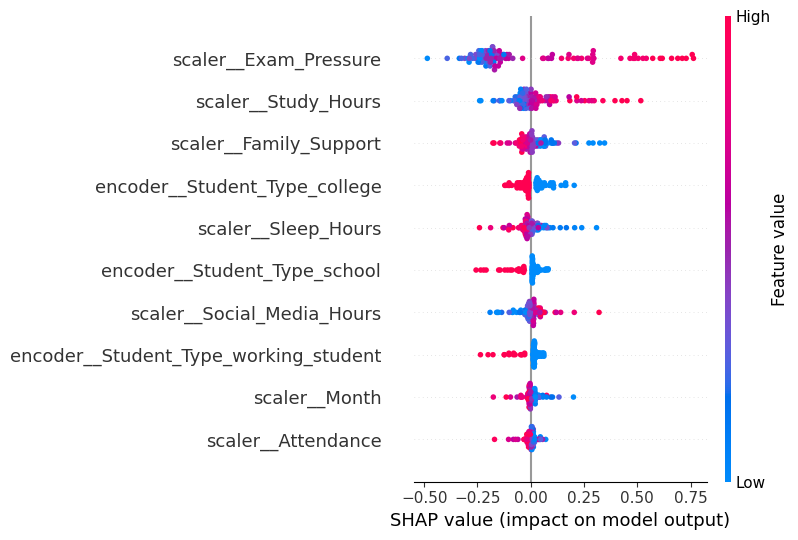

In [45]:
shap.summary_plot(
    shap_test, 
    samples_test
)

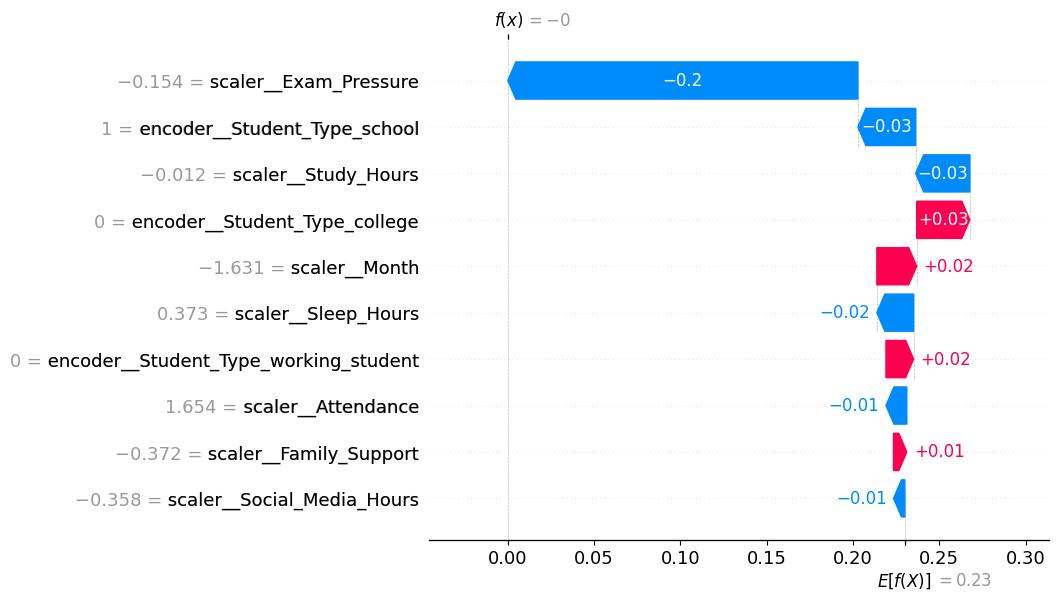

In [46]:
shap.plots.waterfall(
    shap_test[0]
)

<h1>Make Pipeline</h1>

In [47]:
from sklearn.pipeline import Pipeline 

pipeline = Pipeline([
    ("preprocessor", ct),
    ("model", mlp),
])

In [48]:
joblib.dump( pipeline, "pickle_files/student_stress_model.pkl")

['pickle_files/student_stress_model.pkl']